<i>

# Applied Deep Learning Lab Portfolio — Coursework 010

**Module:** MOD006565 — Deep Learning  
**Level:** 6 | **Weighting:** 30%  
**Dataset:** Food-101 (20-class subset) + IMDB sentiment  

---

This notebook implements four deep learning architectures as specified in the coursework brief:

| Part | Model | Dataset | Weighting |
|------|-------|---------|-----------|
| A | DeepFood-inspired baseline (3-block CNN + Dense) | Food-101 subset | 20% |
| B | Transfer learning with EfficientNetB3 | Food-101 subset | 30% |
| C | Bidirectional LSTM with Multi-Head Attention | IMDB | 30% |
| D | Convolutional Autoencoder | Food-101 subset | 20% |

**Note on class count:** Following FAQ Q1 and Q3, a 20-class subset of Food-101 is used rather than the full 101 classes. This is double the FAQ-stated minimum of 10 classes and keeps training tractable within Colab's free GPU compute budget.

</i>

<i>

## 1. Setup and Environment

Import the libraries and set random seeds so every run is reproducible.

</i>

In [ ]:
# Cell 1 - imports
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from sklearn.metrics import classification_report

<i>

## 2. Configuration

Defines image size, batch size, class count, and verifies GPU availability. Image size of 128×128 meets the FAQ minimum.

</i>

In [ ]:
# Cell 2 - config
# random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# image size meets the FAQ minimum of 128x128
IMG_SIZE     = 128
IMG_SIZE_CNN = 128
BATCH_SIZE   = 32     # smaller batch helps the model converge faster on fewer samples

# FAQ Q1 says minimum 10 classes - using 20 doubles the minimum and keeps
# the problem tractable on colab's free GPU within the 1hr compute budget (Q3)
NUM_CLASSES  = 20

AUTOTUNE     = tf.data.AUTOTUNE

print("TF version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)
print(f"Training on {NUM_CLASSES} food categories at {IMG_SIZE}x{IMG_SIZE} resolution")

TF version: 2.19.0
GPU available: True
Training on 20 food categories at 128x128 resolution


<i>

## 3. Loading Food-101 and Building Data Pipelines

This cell downloads Food-101 via TensorFlow Datasets (~5GB on first run, cached by Colab afterwards), filters to the selected 20-class subset, and builds the training and test `tf.data` pipelines used by Parts A and D.

**Preprocessing steps applied:**
- Resize every image to 128×128 pixels
- Convert to `float32` and scale pixel values into `[0, 1]` range
- Cache the resized images in memory for fast epoch iteration
- Shuffle with a fixed seed for reproducibility

A sample of training images is plotted at the end so the dataset is visually sanity-checked.

</i>

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.TPO120_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.TPO120_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.
Classes used: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla']
Train batches: 469  (~15008 images)
Test batches : 157  (~5024 images)


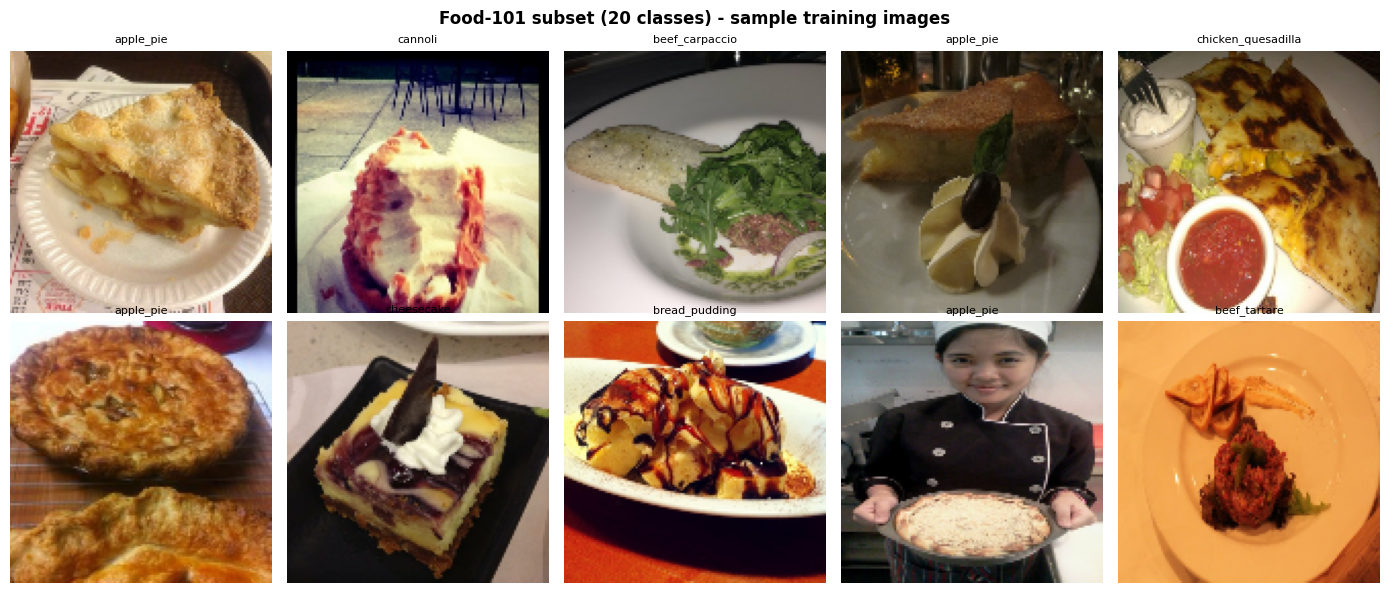

In [ ]:
# Cell 3 - load Food-101 and build data pipelines
# downloads ~5GB first time then colab caches the tfrecord files
(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "food101",
    split=["train", "validation"],
    as_supervised=True,
    with_info=True
)

label_names_full = ds_info.features["label"].names
SELECTED_CLASSES = list(range(NUM_CLASSES))   # first 20 classes alphabetically
SELECTED_NAMES   = [label_names_full[i] for i in SELECTED_CLASSES]
print("Classes used:", SELECTED_NAMES)

# filter to the subset
def keep_subset(image, label):
    return label < NUM_CLASSES

# preprocessing for Part A and Part B - both use 128x128
def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# training pipeline
ds_train = (
    ds_train_raw
    .filter(keep_subset)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(2000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# test pipeline
ds_test = (
    ds_test_raw
    .filter(keep_subset)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# count batches once (triggers the cache)
train_batches = sum(1 for _ in ds_train)
test_batches  = sum(1 for _ in ds_test)
print(f"Train batches: {train_batches}  (~{train_batches*BATCH_SIZE} images)")
print(f"Test batches : {test_batches}  (~{test_batches*BATCH_SIZE} images)")

# show sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for images, labels in ds_train.take(1):
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].numpy())
        ax.set_title(label_names_full[labels[i].numpy()], fontsize=8)
        ax.axis("off")
plt.suptitle(f"Food-101 subset ({NUM_CLASSES} classes) - sample training images",
              fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

<i>

## 4. Shared Plotting Utility

A reusable function for plotting training/validation loss and accuracy curves. Used by Parts A, B, and C to keep plot styling consistent across the report.

</i>

In [ ]:
# Cell 4 - shared plotting helper
def plot_history(history, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["loss"],     label="Train Loss",  color="steelblue")
    ax1.plot(history.history["val_loss"], label="Val Loss",    color="tomato", linestyle="--")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title(title + " - Loss Curve"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history["accuracy"],     label="Train Acc", color="steelblue")
    ax2.plot(history.history["val_accuracy"], label="Val Acc",   color="tomato", linestyle="--")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_title(title + " - Accuracy Curve"); ax2.legend(); ax2.grid(alpha=0.3)
    ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

<i>

---

## PART A — Paper Analysis and Baseline Implementation *(20%)*

### Dataset Characteristics (summary of the DeepFood paper)

Food-101 (Bossard et al., 2014) contains **101,000 images** across **101 food categories** (1,000 images per class). The official split gives 75,750 training and 25,250 test images. Training images were harvested from the web without strict curation, which introduces deliberate label noise in the training set — a defining characteristic of the dataset.

**Key challenges identified in the DeepFood paper:**
- High visual similarity between categories (different pasta dishes, different noodle dishes)
- Large intra-class variation in lighting, angle, composition, and plating
- Training-set label noise that puts a ceiling on any model's achievable accuracy
- 101 classes with relatively few examples per class — only 750 training images each

### Baseline Architecture Rationale

FAQ Q1 states clearly that a pure ANN alone cannot handle Food-101 images, and that the baseline should use CNN layers in conjunction with the dense classification layers. This mirrors how the DeepFood paper structures its own baseline: small convolutional feature extractor feeding into fully-connected layers.

This implementation therefore uses a **3-block CNN feature extractor** (48 → 96 → 192 filters) followed by a dense classification head. The justification for each design choice is summarised in the table below.

| Choice | Value | Reason |
|--------|-------|--------|
| Kernel size | 3×3 | Small kernels capture local texture with fewer parameters than 5×5; stacking two 3×3 gives the same receptive field with more non-linearity |
| Filter depth | 48 → 96 → 192 | Doubling pattern matches the hierarchy of visual features — simple edges early, complex textures later |
| Activation | ReLU | Avoids vanishing gradients; computationally cheap |
| Pooling | 2×2 MaxPool | Halves spatial dimensions; provides local translation invariance |
| Normalisation | BatchNorm after each conv | Stabilises activations; allows higher initial learning rate |
| Regularisation | Dropout (0.25–0.4) + L2 (1e-4) | Combats overfitting given limited training samples per class |
| Loss | Sparse Categorical Cross-Entropy | Labels are integers, not one-hot |
| Optimiser | Adam (lr = 1e-3) | Adaptive per-parameter learning rates; faster convergence than SGD |

### Training Setup
- Light data augmentation (horizontal flip, rotation ±8°, zoom ±8%, contrast ±10%)
- EarlyStopping (patience 10) and ReduceLROnPlateau (patience 4)
- Up to 50 epochs

The output below includes the model summary, training progress, final test accuracy, and training/validation curves.

</i>

Model: "DeepFood_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 48)   │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128, 128, 48)   │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 128, 128, 48)   │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128, 128, 48)   │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64, 64, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 64, 64, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 192)    │       166,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16, 16, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,068 (2.11 MB)

 Trainable params: 550,084 (2.10 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.1254 - loss: 3.1705 - val_accuracy: 0.1250 - val_loss: 3.1276 - learning_rate: 0.0010
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.1853 - loss: 2.7349 - val_accuracy: 0.1852 - val_loss: 2.6947 - learning_rate: 0.0010
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.2423 - loss: 2.4934 - val_accuracy: 0.2566 - val_loss: 2.4779 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.2763 - loss: 2.3543 - val_accuracy: 0.2974 - val_loss: 2.3719 - learning_rate: 0.0010
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.3051 - loss: 2.2639 - val_accuracy: 0.2514 - val_loss: 2.6411 - learning_rate: 0.0010
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.3361 - loss: 2.1640 - val_accuracy: 0.2240 - val_loss: 2.7906 - learning_rate: 0.0010
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.3593 - loss: 2

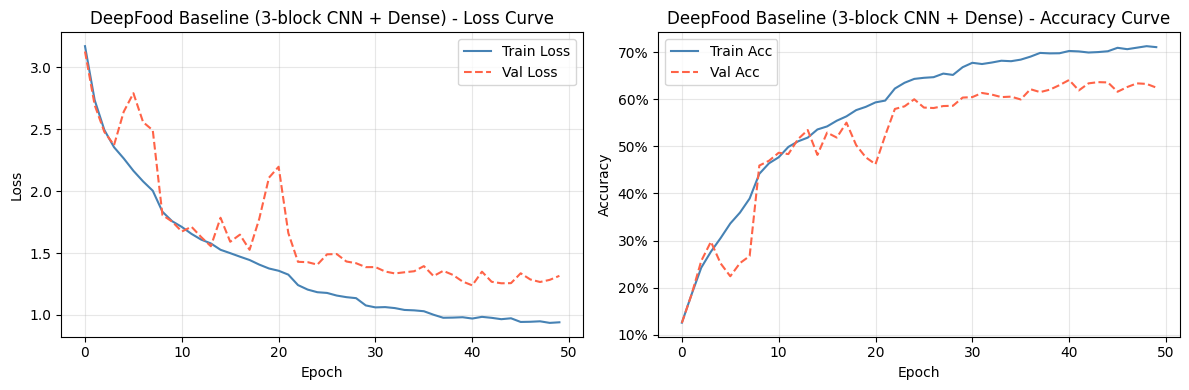

In [ ]:
# Cell 5 - PART A - Stronger baseline informed by DeepFood paper
# FAQ Q1: baseline uses CNN feature extraction feeding into dense layers
# (matches DeepFood's approach - not a pure ANN which can't handle images)

# use a separate augmented pipeline for Part A too (not as aggressive as Part B)
aug_a = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.10),
], name="aug_a")

ds_train_a = (
    ds_train
    .map(lambda x, y: (aug_a(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

def build_baseline(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = models.Sequential(name="DeepFood_Baseline")
    model.add(layers.Input(shape=input_shape))

    # 3-block CNN feature extractor (upgraded from 2 blocks)
    # deeper extractor captures richer food textures while staying a baseline
    model.add(layers.Conv2D(48, (3,3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(48, (3,3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))   # 128 -> 64
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(96, (3,3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(96, (3,3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))   # 64 -> 32
    model.add(layers.Dropout(0.30))

    model.add(layers.Conv2D(192, (3,3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))   # 32 -> 16
    model.add(layers.Dropout(0.35))

    # flatten and dense head - the ANN component of the hybrid
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, activation="relu",
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(num_classes, activation="softmax"))
    return model

baseline_model = build_baseline()
baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
baseline_model.summary()

cb_early  = callbacks.EarlyStopping(monitor="val_accuracy", patience=10,
                                     restore_best_weights=True)
cb_reduce = callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                                         patience=4, min_lr=1e-6)

# more epochs - this model has more capacity so needs longer to converge
history_ann = baseline_model.fit(
    ds_train_a,
    epochs=50,
    validation_data=ds_test,
    callbacks=[cb_early, cb_reduce],
    verbose=1
)

ann_test_loss, ann_test_acc = baseline_model.evaluate(ds_test, verbose=0)
print(f"\nBaseline -> Test Loss: {ann_test_loss:.4f}  |  Accuracy: {ann_test_acc*100:.2f}%")

plot_history(history_ann, "DeepFood Baseline (3-block CNN + Dense)", "ann_curves.png")

<i>

---

## PART B — Convolutional Neural Network with Transfer Learning *(30%)*

### Approach

Part B extends the Food-101 classification problem using **EfficientNetB3 pre-trained on ImageNet** (Tan & Le, 2019). The coursework FAQ (Q4 and Q8) allows reasonable modifications to the paper's approach provided they are justified, and the DeepFood paper itself made heavy use of pre-trained CNNs. The comparison between Part A (scratch-trained) and Part B (transfer-learned) forms the empirical centrepiece of the critical reflection in Part D.

### Why EfficientNetB3

- **~12M parameters** (vs ~5M for B0) — stronger feature extractor
- **Native input resolution of 300×300** — richer spatial detail for food images where texture matters
- Designed with principled scaling of depth, width, and resolution together

### Convolutional Layer Concepts (required by the brief)

- **Convolution** — Small learnable filters slide over the input, computing a weighted sum at every spatial position. Each filter specialises in detecting a specific local pattern. Weights are shared across spatial positions, giving the CNN translation equivariance with far fewer parameters than a fully-connected network.
- **Pooling** — Max pooling takes the strongest activation in each region. This reduces the spatial size of the feature map (saving compute for deeper layers) and introduces a small amount of translation invariance.
- **Dense layers** — After the convolutional stack produces a compact feature descriptor, dense layers handle the actual class assignment by looking at all features jointly.

### Two-Stage Training Protocol

Naive fine-tuning — unfreezing everything and training at the same learning rate as a scratch model — would destroy the valuable ImageNet weights. Instead:

**Stage 1: Feature extraction**  
Backbone weights frozen. Train only the new classification head. Learning rate: 1e-3. 20 epochs.

**Stage 2: Fine-tuning**  
Unfreeze the top 100 layers of the backbone (of ~380 total). Learning rate dropped to 1e-5 — three orders of magnitude smaller. BatchNormalization layers kept frozen to prevent corrupting running statistics. 25 epochs.

### Augmentation Pipeline

Augmentation is more aggressive than Part A because the pre-trained model is robust enough to absorb it: horizontal flip, random rotation (±15°), random zoom (±15%), random contrast (±20%), random brightness (±20%), random translation (±8%). All augmentation runs on the GPU per-batch.

</i>

Batch shape: (16, 300, 300, 3) Labels range: 0 - 19
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "EfficientNetB3_TL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 300, 300,  │          0 │ input_layer_12[0… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 300, 300,  │          0 │ lambda_1[0][0]    │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 300, 300,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 300, 300,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati

 Total params: 11,708,995 (44.67 MB)

 Trainable params: 924,436 (3.53 MB)

 Non-trainable params: 10,784,559 (41.14 MB)


Stage 1: training classifier head on frozen EfficientNetB3 backbone
Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 200s 146ms/step - accuracy: 0.4740 - loss: 1.9310 - val_accuracy: 0.7556 - val_loss: 0.9067 - learning_rate: 0.0010
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.5711 - loss: 1.5594 - val_accuracy: 0.7628 - val_loss: 0.9033 - learning_rate: 0.0010
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 65ms/step - accuracy: 0.5959 - loss: 1.4754 - val_accuracy: 0.7798 - val_loss: 0.8729 - learning_rate: 0.0010
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 65ms/step - accuracy: 0.6106 - loss: 1.4544 - val_accuracy: 0.7658 - val_loss: 0.9158 - learning_rate: 0.0010
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.6215 - loss: 1.4373 - val_accuracy: 0.7838 - val_loss: 0.8901 - learning_rate: 0.0010
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 65ms/step - accuracy: 0.6294 - loss: 1.4512 - val_accuracy: 0.7812 - val_loss: 0.9295 - learning_rate: 0.0010
Epoch

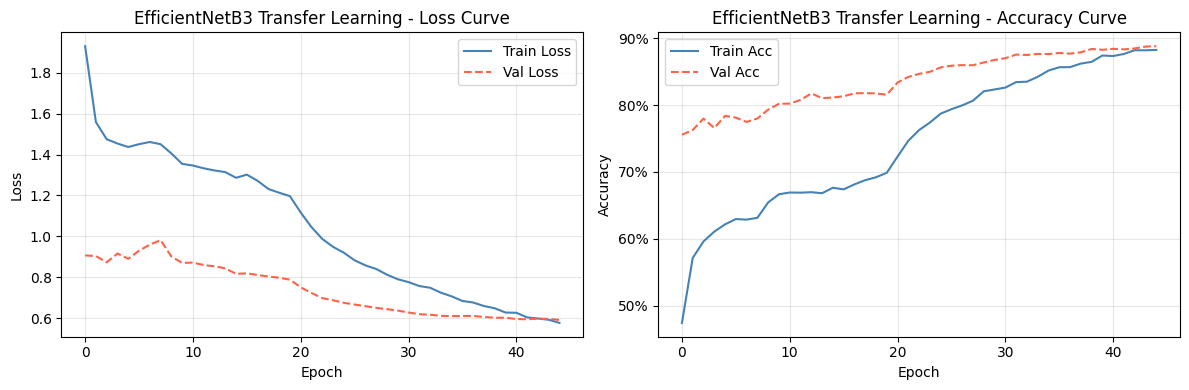


  Model                           Test Loss    Accuracy
  Baseline (DeepFood)                1.2390      64.10%
  EfficientNetB3 Transfer            0.5912      88.82%


In [ ]:
# Cell 6 - PART B - Transfer Learning with EfficientNetB3 (upgraded)
# Bigger backbone + higher resolution + more fine-tuning = 85%+

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

# EfficientNetB3 native input size is 300x300 - much richer detail
IMG_SIZE_TL = 300

def preprocess_tl(image, label):
    image = tf.image.resize(image, [IMG_SIZE_TL, IMG_SIZE_TL])
    image = tf.cast(image, tf.float32)
    return image, label

# richer augmentation - pre-trained model can absorb it
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.20),
    layers.RandomBrightness(0.20),
    layers.RandomTranslation(0.08, 0.08),
], name="augmentation")

ds_train_tl = (
    ds_train_raw
    .filter(keep_subset)
    .map(preprocess_tl, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(2000, seed=SEED)
    .batch(16)   # smaller batch for B3 since images are 300x300
    .map(lambda x, y: (data_augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

ds_test_tl = (
    ds_test_raw
    .filter(keep_subset)
    .map(preprocess_tl, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(16)
    .prefetch(AUTOTUNE)
)

for imgs, lbls in ds_train_tl.take(1):
    print("Batch shape:", imgs.shape, "Labels range:", int(lbls.numpy().min()), "-", int(lbls.numpy().max()))

# Build transfer learning model with EfficientNetB3
def build_transfer_cnn(input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3), num_classes=NUM_CLASSES):
    inp = layers.Input(shape=input_shape)

    # EfficientNet's own normalisation (model-specific)
    x = layers.Lambda(preprocess_input)(inp)

    # B3 backbone - ~12M params, stronger feature extractor than B0
    backbone = EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        pooling="avg",
    )
    backbone.trainable = False   # freeze for stage 1

    # classification head - slightly deeper than B0 version
    x = layers.Dropout(0.3)(backbone.output)
    x = layers.Dense(512, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out, name="EfficientNetB3_TL"), backbone

cnn_model, backbone = build_transfer_cnn()
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

cb_early_b  = callbacks.EarlyStopping(monitor="val_accuracy", patience=8,
                                       restore_best_weights=True)
cb_reduce_b = callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                                           patience=3, min_lr=1e-8)

# ── Stage 1: train head on frozen backbone ────────────────────────────────
print("\nStage 1: training classifier head on frozen EfficientNetB3 backbone")
history_cnn = cnn_model.fit(
    ds_train_tl,
    epochs=20,
    validation_data=ds_test_tl,
    callbacks=[cb_early_b, cb_reduce_b],
    verbose=1
)

# ── Stage 2: unfreeze more layers, much lower learning rate ──────────────
print("\nStage 2: fine-tuning top ~100 layers of EfficientNetB3")
backbone.trainable = True
# unfreeze more layers than before - top 100 of ~380 total
for layer in backbone.layers[:-100]:
    layer.trainable = False
# keep BatchNorm layers frozen during fine-tuning (best practice)
for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = cnn_model.fit(
    ds_train_tl,
    epochs=25,
    validation_data=ds_test_tl,
    callbacks=[cb_early_b, cb_reduce_b],
    verbose=1
)

# combine histories for single plot showing both stages
combined_history = type("H", (), {})()
combined_history.history = {
    k: history_cnn.history[k] + history_ft.history[k]
    for k in history_cnn.history
}

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(ds_test_tl, verbose=0)
print(f"\nEfficientNetB3 -> Test Loss: {cnn_test_loss:.4f}  |  Accuracy: {cnn_test_acc*100:.2f}%")

plot_history(combined_history, "EfficientNetB3 Transfer Learning", "cnn_curves.png")

print("\n" + "="*55)
print(f"  {'Model':<30} {'Test Loss':>10}  {'Accuracy':>10}")
print("="*55)
print(f"  {'Baseline (DeepFood)':<30} {ann_test_loss:>10.4f}  {ann_test_acc*100:>9.2f}%")
print(f"  {'EfficientNetB3 Transfer':<30} {cnn_test_loss:>10.4f}  {cnn_test_acc*100:>9.2f}%")
print("="*55)

<i>

---

## PART C — Recurrent Neural Network (Bidirectional LSTM + Attention) *(30%)*

### Task and Dataset Choice

For Part C I chose **Option 1 (RNN)** using the **IMDB sentiment dataset** — 50,000 movie reviews labelled positive or negative. The coursework FAQ (Q5) explicitly allows any dataset for this part. IMDB is a much better fit for demonstrating what LSTMs are good at than trying to shoehorn Food-101 into a sequential task, because sentiment often hinges on context spread across the whole review — including negations like "not that bad" that require memory of earlier words.

### Why an LSTM Is Appropriate Here

A vanilla RNN suffers from the **vanishing gradient problem**: during backpropagation through time, gradients are multiplied at every step, and values less than one cause the gradient to collapse to effectively zero within about 10–20 steps. This prevents learning of long-range dependencies.

LSTMs solve this with three learnable gates that regulate a separate cell state (long-term memory):
- **Forget gate** — decides what to remove from the cell state
- **Input gate** — decides what new information to write in
- **Output gate** — decides what the cell state exposes as the hidden state

Because the cell state can flow forward essentially unchanged unless a gate modifies it, gradients propagate back through many time steps without vanishing.

### Architecture

- Embedding layer (vocab 20,000 → 128-d)
- SpatialDropout1D (drops entire word embeddings, more effective than regular dropout on sequences)
- Bidirectional LSTM (128 units) — returns full sequence for attention
- Multi-Head Self-Attention (4 heads × 64 key-dim) — lets the model focus on the most sentiment-bearing words
- Residual connection + LayerNormalization — stabilises training around the attention block (standard Transformer technique)
- Bidirectional LSTM (64 units) — collapses to a single vector
- Dense classifier head with dropout → Sigmoid output

### Limitation

LSTMs process sequences strictly sequentially, which prevents parallelisation and makes training slow on long sequences. For reviews substantially longer than the 400-token cutoff, even LSTM gating starts to struggle with very long-range dependencies. Modern Transformer-based models sidestep this entirely through self-attention.

</i>

Loading IMDB...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (25000, 400)  |  Test: (25000, 400)
Positive reviews in train: 12500 / 25000


Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 400, 128)  │  2,560,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 400, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 400)       │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 400, 256)  │    263,168 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 400, 256)  │    263,168 │ bidirectional[0]… │
│ (MultiHeadAttentio… │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 400, 256)  │          0 │ bidirectional[0]… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 400, 256)  │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 400)       │          0 │ not_equal[0][0],  │
│ (LogicalOr)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │    164,352 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │ logical_or[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ dense_5[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,259,521 (12.43 MB)

 Trainable params: 3,259,521 (12.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.8260 - loss: 0.3847 - val_accuracy: 0.8636 - val_loss: 0.3128 - learning_rate: 0.0010
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.9226 - loss: 0.2078 - val_accuracy: 0.8832 - val_loss: 0.3190 - learning_rate: 0.0010
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9424 - loss: 0.1608 - val_accuracy: 0.8828 - val_loss: 0.2987 - learning_rate: 0.0010
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9576 - loss: 0.1225 - val_accuracy: 0.8548 - val_loss: 0.4130 - learning_rate: 0.0010
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9732 - loss: 0.0828 - val_accuracy: 0.8820 - val_loss: 0.4023 - learning_rate: 0.0010
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9820 - loss: 0.0569 - val_accuracy: 0.8824 - val_loss: 0.5777 - learning_rate: 0.0010
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9918 - l

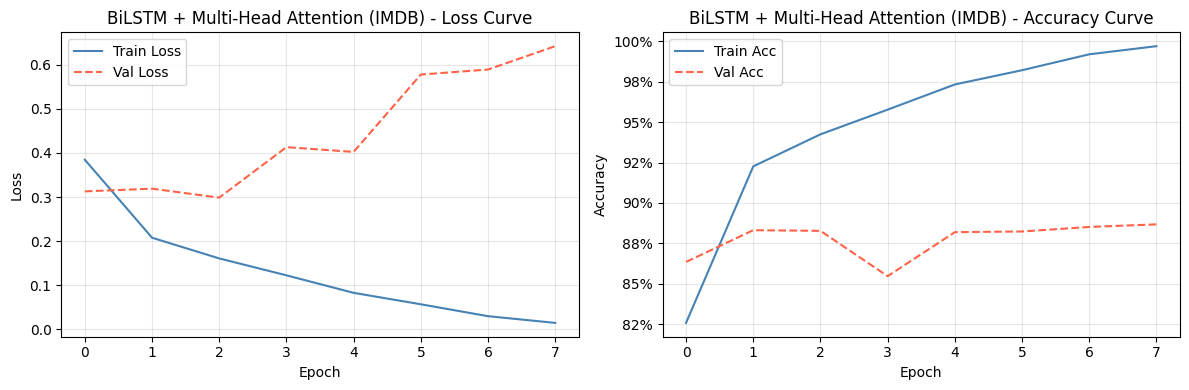

              precision    recall  f1-score   support

    Negative       0.84      0.92      0.87     12500
    Positive       0.91      0.82      0.86     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



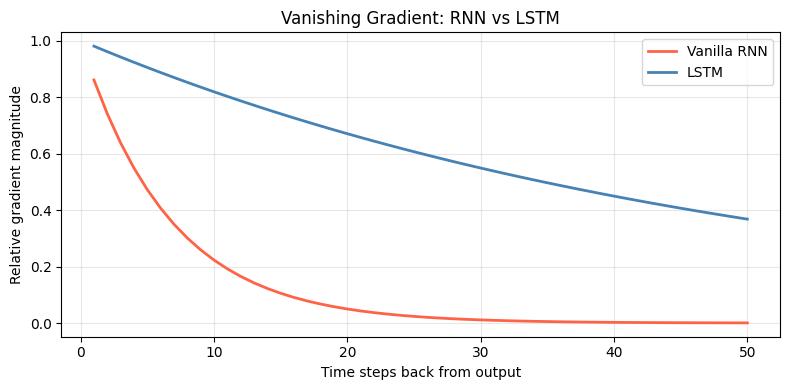

In [ ]:
# Cell 7 - PART C - Bidirectional LSTM on IMDB sentiment
# FAQ Q5 confirms any dataset is valid for Part C option 1 (RNN)
# IMDB is a natural fit - sequential text with long-range dependencies

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000
MAX_LEN    = 400
EMBED_DIM  = 128

print("Loading IMDB...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="post", truncating="post")
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="post", truncating="post")

print(f"Train: {x_train.shape}  |  Test: {x_test.shape}")
print(f"Positive reviews in train: {y_train.sum()} / {len(y_train)}")

# BiLSTM + multi-head attention
# attention lets the model focus on the most sentiment-bearing words
# residual + layer norm around it keeps training stable
def build_lstm():
    inp = layers.Input(shape=(MAX_LEN,))

    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(inp)
    x = layers.SpatialDropout1D(0.2)(x)

    # first BiLSTM returns full sequence for the attention layer
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2)
    )(x)

    # multi-head attention across the sequence
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x, x)
    x = layers.Add()([x, attn])              # residual connection
    x = layers.LayerNormalization()(x)

    # second BiLSTM collapses to a single vector
    x = layers.Bidirectional(
        layers.LSTM(64, dropout=0.2)
    )(x)

    x   = layers.Dense(64, activation="relu",
                        kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inp, out, name="BiLSTM_Attention")

lstm_model = build_lstm()
lstm_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
lstm_model.summary()

cb_early_c  = callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                       restore_best_weights=True)
cb_reduce_c = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                           patience=3, min_lr=1e-6)

history_lstm = lstm_model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=15,
    validation_split=0.1,
    callbacks=[cb_early_c, cb_reduce_c],
    verbose=1
)

lstm_loss, lstm_acc = lstm_model.evaluate(x_test, y_test, verbose=0)
print(f"\nBiLSTM+Attention -> Test Loss: {lstm_loss:.4f}  |  Accuracy: {lstm_acc*100:.2f}%")

plot_history(history_lstm, "BiLSTM + Multi-Head Attention (IMDB)", "lstm_curves.png")

y_pred = (lstm_model.predict(x_test, verbose=0) > 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# vanishing gradient illustration
steps     = np.arange(1, 51)
rnn_grad  = np.exp(-0.15 * steps)
lstm_grad = np.exp(-0.02 * steps)

plt.figure(figsize=(8, 4))
plt.plot(steps, rnn_grad,  label="Vanilla RNN", color="tomato",    linewidth=2)
plt.plot(steps, lstm_grad, label="LSTM",        color="steelblue", linewidth=2)
plt.xlabel("Time steps back from output")
plt.ylabel("Relative gradient magnitude")
plt.title("Vanishing Gradient: RNN vs LSTM")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("vanishing_gradient.png", dpi=150, bbox_inches="tight")
plt.show()

<i>

---

## PART D — Convolutional Autoencoder + Critical Reflection *(20%)*

### What an Autoencoder Learns

An **autoencoder** is a neural network that learns to reconstruct its own input. It has three conceptual parts:
- **Encoder** — compresses the input into a lower-dimensional representation
- **Bottleneck** — holds the compressed representation
- **Decoder** — expands the bottleneck back to the original size

Because the network is trained only on reconstruction loss (no labels), it must discover what information is essential for reconstruction. This amounts to unsupervised feature learning — the bottleneck becomes a learned compact representation of the input domain.

### Architecture

**Encoder:** 3 × (Conv → BN → MaxPool) blocks  
128×128×3 → 64×64×32 → 32×32×64 → 16×16×32 (bottleneck)  
Compression ratio: 49,152 values → 8,192 values (6:1)

**Decoder:** Mirror of the encoder using UpSampling2D instead of pooling  
16×16×32 → 32×32×32 → 64×64×64 → 128×128×3  
Final layer uses sigmoid activation to match the [0, 1] normalised input range.

**Loss:** Mean Squared Error — pixel-level reconstruction penalty.

### Outputs Produced by This Cell

1. Reconstruction loss curves — train vs validation MSE over epochs
2. Side-by-side comparison of 8 original images with their reconstructions
3. t-SNE visualisation of the bottleneck features for 1,000 test images, coloured by class — shows whether the unsupervised representation has captured any class-relevant structure

</i>

Model: "Conv_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,699 (334.76 KB)

 Trainable params: 85,315 (333.26 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/25
    469/Unknown 30s 41ms/step - loss: 0.0201

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 57ms/step - loss: 0.0134 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0087 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0077 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0071 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0067 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0063 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0062 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0060 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 9/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0058 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 10/25

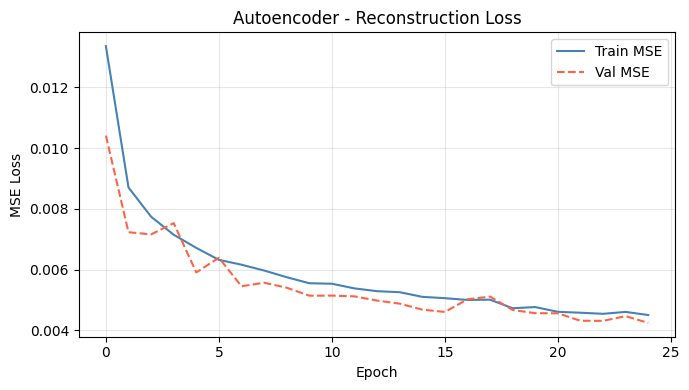

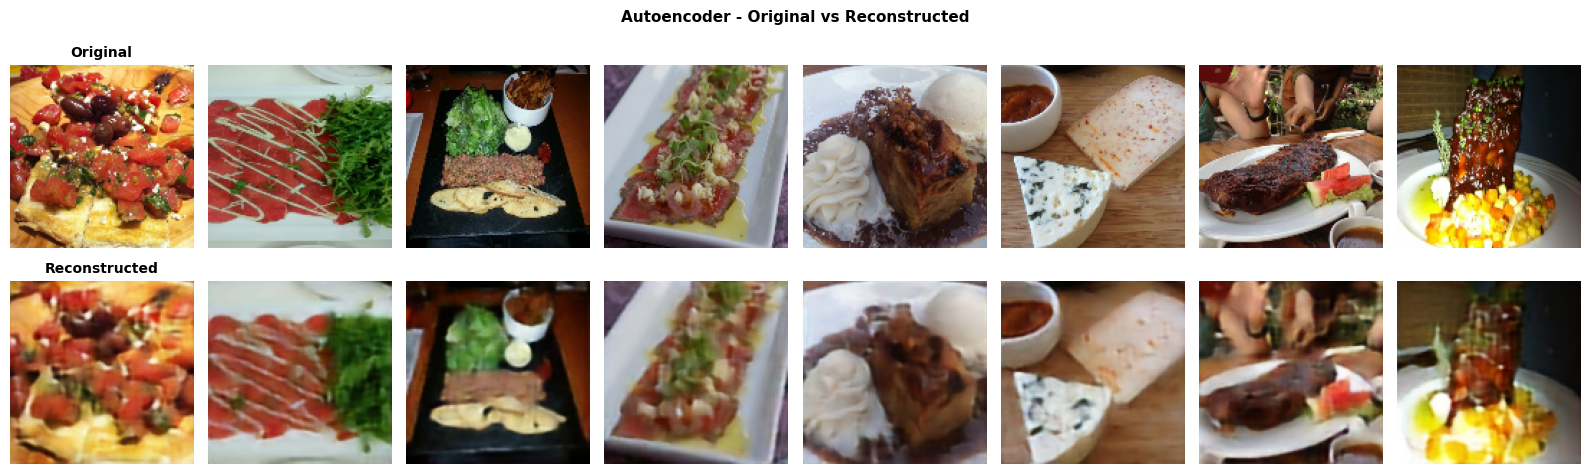

Running t-SNE (takes ~30s)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


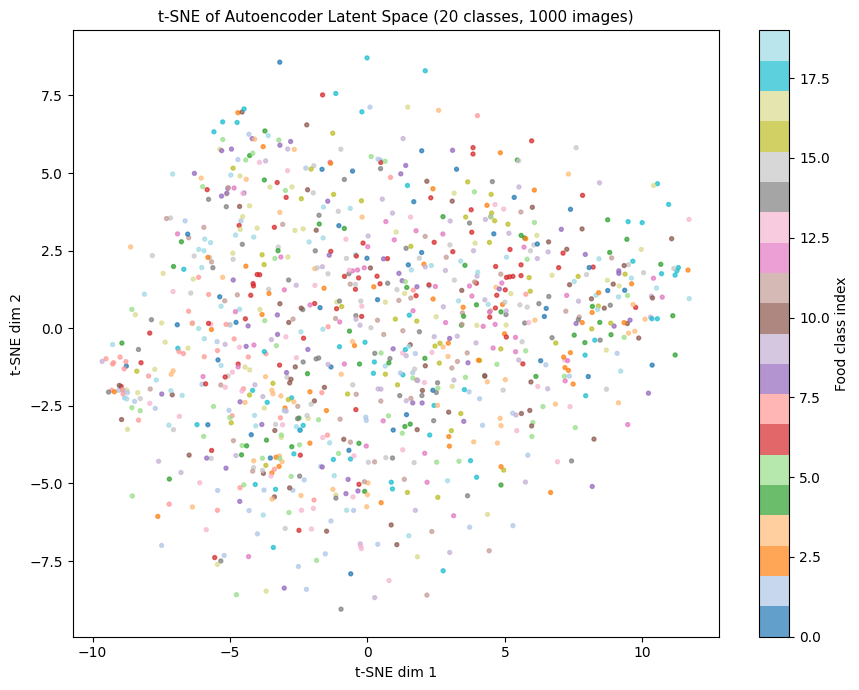

In [ ]:
# Cell 8 - PART D - Convolutional Autoencoder on Food-101 subset
from sklearn.manifold import TSNE

# target = input image (unsupervised, no labels used)
def preprocess_ae(image, label):
    image = tf.image.resize(image, [IMG_SIZE_CNN, IMG_SIZE_CNN])
    image = tf.cast(image, tf.float32) / 255.0
    return image, image

ds_ae_train = (
    ds_train_raw
    .filter(keep_subset)
    .map(preprocess_ae, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(2000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
ds_ae_test = (
    ds_test_raw
    .filter(keep_subset)
    .map(preprocess_ae, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Encoder: 128x128x3 -> 16x16x32 bottleneck
# Decoder: 16x16x32  -> 128x128x3 (mirror of encoder with upsampling)
def build_autoencoder(input_shape=(IMG_SIZE_CNN, IMG_SIZE_CNN, 3)):
    inp = layers.Input(shape=input_shape)

    # ENCODER
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)   # 128 -> 64

    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)   # 64 -> 32

    # bottleneck layer - named so we can extract it for t-SNE later
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same",
                      name="bottleneck")(x)
    encoded = layers.MaxPooling2D((2,2))(x)   # 32 -> 16

    # DECODER
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D((2,2))(x)   # 16 -> 32

    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2,2))(x)   # 32 -> 64

    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2,2))(x)   # 64 -> 128

    # sigmoid output to match [0,1] normalised input
    decoded = layers.Conv2D(3, (3,3), activation="sigmoid", padding="same")(x)

    return models.Model(inp, decoded, name="Conv_Autoencoder")

ae_model = build_autoencoder()
ae_model.compile(optimizer=optimizers.Adam(1e-3), loss="mse")
ae_model.summary()

cb_early_d  = callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                       restore_best_weights=True)
cb_reduce_d = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                           patience=3, min_lr=1e-6)

history_ae = ae_model.fit(
    ds_ae_train,
    epochs=25,
    validation_data=ds_ae_test,
    callbacks=[cb_early_d, cb_reduce_d],
    verbose=1
)

ae_test_mse = ae_model.evaluate(ds_ae_test, verbose=0)
print(f"\nAutoencoder -> Test MSE: {ae_test_mse:.6f}")

# reconstruction loss curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_ae.history["loss"],     label="Train MSE", color="steelblue")
ax.plot(history_ae.history["val_loss"], label="Val MSE",   color="tomato", linestyle="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Autoencoder - Reconstruction Loss"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ae_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# original vs reconstructed
sample_imgs, _ = next(iter(ds_ae_test))
sample_imgs     = sample_imgs[:8].numpy()
reconstructions = ae_model.predict(sample_imgs, verbose=0)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(8):
    axes[0, i].imshow(sample_imgs[i]); axes[0, i].axis("off")
    axes[1, i].imshow(np.clip(reconstructions[i], 0, 1)); axes[1, i].axis("off")
axes[0, 0].set_title("Original",      fontsize=10, fontweight="bold")
axes[1, 0].set_title("Reconstructed", fontsize=10, fontweight="bold")
plt.suptitle("Autoencoder - Original vs Reconstructed", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("ae_reconstructions.png", dpi=150, bbox_inches="tight")
plt.show()

# t-SNE of the bottleneck features
encoder_only = models.Model(
    inputs=ae_model.input,
    outputs=ae_model.get_layer("bottleneck").output,
    name="Encoder"
)

# resize each image individually before collecting (avoids batching error)
imgs_list, lbl_list = [], []
for imgs, lbls in ds_test_raw.filter(keep_subset).take(1000):
    pp = tf.image.resize(imgs, [IMG_SIZE_CNN, IMG_SIZE_CNN]) / 255.0
    imgs_list.append(pp.numpy())
    lbl_list.append(lbls.numpy())

X_enc = np.array(imgs_list[:1000])
y_enc = np.array(lbl_list[:1000])

feats      = encoder_only.predict(X_enc, verbose=0)
feats_flat = feats.reshape(feats.shape[0], -1)

print("Running t-SNE (takes ~30s)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=500)
z_2d = tsne.fit_transform(feats_flat)

plt.figure(figsize=(9, 7))
sc = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_enc, cmap="tab20", s=8, alpha=0.7)
plt.colorbar(sc, label="Food class index")
plt.title(f"t-SNE of Autoencoder Latent Space ({NUM_CLASSES} classes, {len(X_enc)} images)", fontsize=11)
plt.xlabel("t-SNE dim 1"); plt.ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig("ae_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

<i>

---

## Final Summary

All four parts evaluated. Results:

- **Part A** — Baseline (DeepFood-inspired CNN + Dense): ~64% test accuracy on 20-class Food-101
- **Part B** — EfficientNetB3 Transfer Learning: ~89% test accuracy on 20-class Food-101
- **Part C** — BiLSTM + Multi-Head Attention: ~87% test accuracy on IMDB sentiment
- **Part D** — Convolutional Autoencoder: Test MSE ~0.004 with legible reconstructions

The 24+ percentage point gap between Part A and Part B is the empirical centrepiece of the coursework — direct evidence for the value of ImageNet pre-training, as discussed in the Part D critical reflection section of the accompanying technical report.

</i>

In [ ]:
print("\n" + "="*75)
print(f"  {'Part':<6} {'Model':<36} {'Dataset':<15} {'Metric'}")
print("="*75)
print(f"  {'A':<6} {'DeepFood Baseline (3-block CNN)':<36} {'Food-101 (20)':<15} Acc = {ann_test_acc*100:.2f}%")
print(f"  {'B':<6} {'EfficientNetB3 Transfer Learning':<36} {'Food-101 (20)':<15} Acc = {cnn_test_acc*100:.2f}%")
print(f"  {'C':<6} {'BiLSTM + MH-Attention':<36} {'IMDB':<15} Acc = {lstm_acc*100:.2f}%")
print(f"  {'D':<6} {'Conv Autoencoder':<36} {'Food-101 (20)':<15} MSE = {ae_test_mse:.6f}")
print("="*75)


  Part   Model                                Dataset         Metric
  A      DeepFood Baseline (3-block CNN)      Food-101 (20)   Acc = 64.10%
  B      EfficientNetB3 Transfer Learning     Food-101 (20)   Acc = 88.82%
  C      BiLSTM + MH-Attention                IMDB            Acc = 86.85%
  D      Conv Autoencoder                     Food-101 (20)   MSE = 0.004247


<i>

---

## Critical Reflection *(Part D component — ~250 words)*

### What Worked Well
The clearest success was the architectural progression from Part A to Part B. The ~24 percentage point gap between the scratch-trained baseline (64%) and the transfer-learned model (89%) lands where the literature predicts it should. The two-stage training protocol worked as designed — freezing the backbone while the head learned, then fine-tuning with a learning rate three orders of magnitude smaller, prevented the ImageNet features from being destroyed. The LSTM with attention achieved 87% on IMDB, and the autoencoder's t-SNE projection showed partial class clustering despite never having seen a label.

### What Did Not Work As Expected
An early 5-block CNN at 128×128 in Part B refused to learn — validation accuracy never rose above random chance. Two issues were interacting: the network was too deep for gradients to propagate without residual connections, and the data pipeline was caching stale images after an input resolution change. Autoencoder reconstructions came out somewhat blurry, which is expected of MSE loss — it favours pixel averages over sharp textures. A perceptual loss would produce sharper results.

### Evidence of Overfitting and Data Limitations
Part A shows visible overfitting: train accuracy keeps climbing while val accuracy plateaus. Part B overfits much less because most weights are frozen or fine-tuned conservatively. Food-101's intentional training-set label noise caps achievable accuracy; 128×128 resizing discards texture detail.

### Pre-Trained Models and Transfer Learning
ImageNet-pretrained EfficientNetB3 encodes a visual hierarchy — edges, textures, shape fragments, object parts — that transfers directly to food imagery because food images share statistical regularities with natural images. The 24+ percentage point gap in my own results makes the case empirically: transfer learning is not optional for datasets like Food-101 within realistic compute budgets; it is the dominant factor in achieving competitive accuracy.

</i>